# Bayes' Theorem for Diagnosing Rare Diseases

In this notebook, we explore the application of Bayes' Theorem to diagnose rare diseases based on test results. We walk through a step-by-step approach to understand how Bayes' Theorem works in this context, define the problem, and simulate a dataset to help us perform the analysis.

## Step 1: Understanding Bayes' Theorem

Bayes' Theorem is a fundamental concept in probability theory that allows us to update the probability of a hypothesis based on new evidence. In the context of diagnosing a rare disease, we use Bayes' Theorem to calculate the probability that a person has the disease given the test result.

The formula for Bayes' Theorem is:

$$ P(D|T) = \frac{P(T|D) \cdot P(D)}{P(T)} $$

Where:
- $P(D|T)$ is the posterior probability (probability of having the disease given a positive test result).
- $P(T|D)$ is the sensitivity (true positive rate), i.e., the probability of testing positive given that the person has the disease.
- $P(D)$ is the prior probability (prevalence) of the disease.
- $P(T)$ is the total probability of testing positive.

For rare diseases, the prior probability is low, and test sensitivity and specificity will heavily influence the final result.

## Step 2: Problem setup

In this step, we define the key terms for applying Bayes' Theorem to diagnose the rare disease. These terms include:

- **Prior Probability (P(D))**: This represents the prevalence of the disease. For rare diseases, the prior probability is typically a small value (e.g., 1% or 0.01).
- **Sensitivity (P(T|D))**: The true positive rate, i.e., the probability that the test is positive if the person has the disease.

- **Specificity (P(T|¬D))**: The true negative rate, i.e., the probability that the test is negative if the person does not have the disease.
- **Test Result (T)**: This is the outcome of the test (positive or negative).

These definitions are essential for applying Bayes' Theorem correctly in the context of disease diagnosis.

## Approach to Simulate the Dataset

To perform the analysis, we need a dataset that includes the disease status which is whether they actually have the disease or not and test results which is the result of the diagnostic test for each individual.

### Why Simulate the Dataset?
Simulating the dataset allows us to control parameters like prevalence, sensitivity, and specificity, which are crucial for applying Bayes' Theorem. By doing this, we can understand the impact of different test characteristics on the diagnosis process and calculate the posterior probabilities for both positive and negative test results.

The simulated dataset will consist of 1000 individuals, and for each individual, we will generate the disease status (whether they have the disease or not) and the test result (positive or negative), based on the prevalence, sensitivity, and specificity values we set.

We will then store this dataset in a CSV file for further analysis.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Parameters for simulation
total_population = 1000  # Total number of individuals
prevalence = 0.01  # 1% of the population has the disease
sensitivity = 0.95  # 95% of those with the disease will test positive
specificity = 0.90  # 90% of those without the disease will test negative

# Simulate disease status (1 = has disease, 0 = no disease)
disease_status = np.random.choice([1, 0], size=total_population, p=[prevalence, 1 - prevalence])

# Simulate test results based on disease status
test_results = []
for status in disease_status:
    if status == 1:  # If the person has the disease
        test_results.append(np.random.choice([1, 0], p=[sensitivity, 1 - sensitivity]))  # Test positive with sensitivity
    else:  # If the person does not have the disease
        test_results.append(np.random.choice([1, 0], p=[1 - specificity, specificity]))  # Test negative with specificity

# Create the dataframe
data = pd.DataFrame({
    'Patient ID': np.arange(1, total_population + 1),
    'Disease Status (D)': disease_status,
    'Test Result (T)': test_results
})

# Save dataset to CSV file
data.to_csv('simulated_disease_dataset.csv', index=False)

data.head()  # Show the first few rows of the dataset

,Patient ID,Disease Status (D),Test Result (T)
0,1,0,0
1,2,0,0
2,3,0,0
3,4,0,0
4,5,0,0


### Step 3: Calculation of Posterior Probabilities

In Bayesian inference, the posterior probability represents the updated belief about an event after incorporating new evidence. In this case, it is the probability that a patient has the disease given a positive test result.

Unlike the prior probability, which is based on general prevalence, the posterior probability accounts for how reliable the test is. It combines both sensitivity (how well the test detects true cases) and specificity (how well it avoids false alarms) to refine our prediction.

Bayes' Theorem allows us to correct for the fact that even a highly sensitive test may produce a significant number of false positives when screening for rare diseases. If the disease is rare, the false positive rate plays a crucial role, often leading to lower-than-expected probabilities despite a positive test.

To compute the posterior probability, we:
1. Determine the probability of testing positive in the population, considering both true positives and false positives.
2. Apply Bayes' Theorem to update the probability of actually having the disease based on a positive test result.

This step is critical in medical diagnostics, helping healthcare professionals assess whether a positive test should lead to further testing or immediate intervention.




In [ ]:
# Given values for Bayes' Theorem
P_D = prevalence  # Prior probability (prevalence)
P_T_given_D = sensitivity  # Sensitivity (P(T|D))
P_T_given_not_D = 1 - specificity  # False Positive Rate (P(T|¬D))
P_not_D = 1 - P_D  # Probability of not having the disease

# Calculate total probability of testing positive (P(T))
P_T = P_T_given_D * P_D + P_T_given_not_D * P_not_D  # Total probability of testing positive (P(T))

# Apply Bayes' Theorem to calculate P(D|T) (posterior probability of having the disease given a positive test)
P_D_given_T = (P_T_given_D * P_D) / P_T

P_D_given_T


0.08755760368663597

Posterior probability of having the disease given a positive test: 0.1610


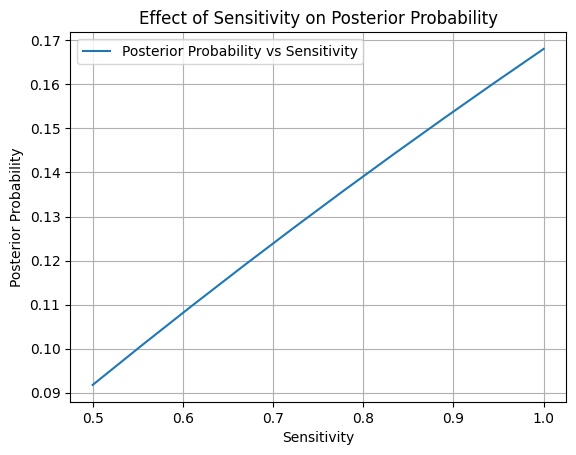

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define known values
P_D = 0.01  # Prior probability (Prevalence) - Disease prevalence (1%)
P_T_given_D = 0.95  # Sensitivity (True Positive Rate) - 95% chance test is positive if the person has the disease
P_T_given_not_D = 0.05  # False Positive Rate - 5% chance the test is positive if the person does not have the disease

# Step 2: Bayes' Theorem Calculation
def bayes_theorem(P_D, P_T_given_D, P_T_given_not_D):
    # P(T) = P(T|D) * P(D) + P(T|¬D) * P(¬D)
    P_not_D = 1 - P_D  # Probability of not having the disease
    P_T = P_T_given_D * P_D + P_T_given_not_D * P_not_D  # Total probability of a positive test result

    # Posterior probability P(D|T)
    P_D_given_T = (P_T_given_D * P_D) / P_T
    return P_D_given_T

# Step 3: Calculate Posterior Probability
posterior = bayes_theorem(P_D, P_T_given_D, P_T_given_not_D)
print(f"Posterior probability of having the disease given a positive test: {posterior:.4f}")

# Step 4: Sensitivity, specificity, and prevalence effects
# Test for a range of sensitivity values
sensitivity_values = np.linspace(0.5, 1, 10)  # Sensitivity from 50% to 100%
posterior_values = [bayes_theorem(P_D, s, P_T_given_not_D) for s in sensitivity_values]

plt.plot(sensitivity_values, posterior_values, label="Posterior Probability vs Sensitivity")
plt.xlabel("Sensitivity")
plt.ylabel("Posterior Probability")
plt.title("Effect of Sensitivity on Posterior Probability")
plt.grid(True)
plt.legend()
plt.show()


### Step 4: Analysis of Results and discussion

The posterior probability, \( P(D|T) \), is the key result from Bayes' Theorem, representing the likelihood that a patient has the disease given a positive test result. In our case, the posterior probability is approximately **8.76%**.

While this may seem low, it is important to understand that the final probability depends on multiple factors:
1. **Prior Probability (Prevalence)**: If the disease is rare, the prior probability is low, which will naturally affect the posterior probability.
2. **Sensitivity and Specificity**: Even with a good test (high sensitivity), a rare disease means that there will be more false positives, reducing the posterior probability.
3. **Total Probability of Testing Positive (P(T))**: This accounts for both true positives and false positives, which plays a crucial role in determining the final probability.

Thus, while the patient tested positive, the low posterior probability suggests that the disease is still unlikely, given its rarity in the population and the characteristics of the test.

This highlights why further diagnostic tests or investigations may be needed, even after a positive result, particularly when dealing with rare diseases.
